# Compute Trace — Rank-Remap to Transformer Workload

FedScale's `client_device_capacity.json` stores per-client MobileNet-V3 inference
latency in ms. ModernBERT-LoRA / Llama-LoRA training is a far heavier transformer
workload, so we **keep FedScale's trace IDs and rank ordering** but swap the
absolute latencies for samples drawn from a *transformer* latency distribution
(GPT-2 CPU-F from AI Benchmark).

Pipeline:
1. Parse `ai-benchmark-ranking-*.html` → `(model, soc, ram_gb)`
2. Parse `ai-benchmark-*-results.html` → `(model, soc, gpt2_cpu_f_ms)`
3. Inner-join on model name (max-RAM-per-model). Report unmatched.
4. Filter RAM ≥ 6 GB (training ModernBERT-base / Llama-3.2-1B with LoRA).
   Drop zeros (failed AI Benchmark runs). **No IQR** — RAM cut is the filter.
5. Rank-remap FedScale source trace into the filtered transformer latency dist.
6. Apply ×3 forward+backward+optimizer multiplier as a config knob.

Output: `traces/client_device_capacity.json` (overwrites the FedScale source
with the same schema; original is preserved at `_legacy/`).

In [20]:
!pip install beautifulsoup4


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
from __future__ import annotations

import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from bs4 import BeautifulSoup

# -- Knobs --
RAM_THRESHOLD_GB = 6
TRAIN_MULTIPLIER = 2.0   # forward+backward+opt vs forward-only inference
OUT_PATH = Path("client_device_capacity.json")

RANKING_HTML = Path("_legacy/computation/ai-benchmark-ranking-2026-04-28.html")
RESULTS_HTML = Path("_legacy/computation/ai-benchmark-2026-04-20-15-47-53.html")
SOURCE_TRACE = Path("fedscale_client_device_capacity.json")  # FedScale

## Step 1 — Parse ranking page (model → RAM)

In [22]:
def parse_ranking(html_path: Path) -> pd.DataFrame:
    soup = BeautifulSoup(html_path.read_text(encoding="utf-8"), "html.parser")
    table = soup.find("table", id="scoreTable")
    rows = []
    for tr in table.find_all("tr"):
        cols = tr.find_all("td")
        if not cols:
            continue
        model_a = cols[0].find("a")
        if not model_a:
            continue
        model = model_a.get_text(strip=True)
        soc = cols[1].get_text(strip=True)
        ram_str = cols[2].get_text(strip=True)
        m = re.match(r"(\d+)\s*GB", ram_str)
        if not m:
            continue
        rows.append({"model": model, "soc": soc, "ram_gb": int(m.group(1))})
    return pd.DataFrame(rows)

df_rank = parse_ranking(RANKING_HTML)
df_rank = df_rank.groupby("model", as_index=False).agg(
    ram_gb=("ram_gb", "max"), soc=("soc", "first")
)
print(f"Ranking rows: {len(df_rank)} unique models")
print("RAM distribution:")
print(df_rank["ram_gb"].value_counts().sort_index())
df_rank

Ranking rows: 615 unique models
RAM distribution:
ram_gb
1       4
2      14
3      29
4      79
6      89
8     194
12    148
16     57
24      1
Name: count, dtype: int64


,model,ram_gb,soc
0,Apple iPhone 15 Pro,8,Apple A17 Pro
1,Apple iPhone 16 Pro,8,Apple A18 Pro
2,Apple iPhone 17 Pro,12,Apple A19 Pro
3,Asus Fonepad 7,1,Intel Atom Z2560
4,Asus ROG Phone 3,12,Snapdragon 865+
...,...,...,...
610,vivo iQOO Neo9 Pro,16,Dimensity 9300
611,vivo iQOO Neo9S Pro,12,Dimensity 9300+
612,vivo iQOO Z10,12,Snapdragon 7s Gen 3
613,vivo iQOO Z9,8,Snapdragon 7 Gen 3


## Step 2 — Parse phone results page (model → GPT-2 CPU-F latency)

In [23]:
def parse_results_gpt2(html_path: Path) -> pd.DataFrame:
    df = pd.read_html(html_path)[0]
    phone_col   = df.columns[df.iloc[1].str.contains(r"Phone\s+Model", regex=True, na=False)][0]
    chipset_col = df.columns[df.iloc[1] == "Chipset"][0]
    gpt2_col = None
    for c in df.columns:
        if str(df.iloc[1, c]).strip() == "GPT-2" and str(df.iloc[2, c]).strip() == "CPU-F":
            gpt2_col = c; break
    assert gpt2_col is not None, "GPT-2 CPU-F column not found"
    out = df.iloc[5:][[phone_col, chipset_col, gpt2_col]].copy()
    out.columns = ["model", "soc", "gpt2_cpu_f_ms"]
    out["gpt2_cpu_f_ms"] = pd.to_numeric(out["gpt2_cpu_f_ms"], errors="coerce")
    out = out.dropna(subset=["gpt2_cpu_f_ms"])
    return out.reset_index(drop=True)

df_results = parse_results_gpt2(RESULTS_HTML)
print(f"Results rows: {len(df_results)}  (zero/non-numeric dropped already? no — see next cell)")
df_results.head()

Results rows: 633  (zero/non-numeric dropped already? no — see next cell)


,model,soc,gpt2_cpu_f_ms
0,Honor Magic8 Pro,Snapdragon 8 Elite Gen 5,117
1,vivo X300 Pro,Dimensity 9500,55
2,vivo X300,Dimensity 9500,55
3,Oppo Find X9 Pro,Dimensity 9500,59
4,Oppo Find X9,Dimensity 9500,59


## Step 3 — Join + RAM filter + drop zeros

Normalization: lowercase + collapse whitespace. We keep the original `model` for
diagnostics and join on a normalized key.

In [24]:
def norm(name: str) -> str:
    return re.sub(r"\s+", " ", str(name).strip().lower())

df_rank["_key"]    = df_rank["model"].map(norm)
df_results["_key"] = df_results["model"].map(norm)

joined = df_results.merge(
    df_rank[["_key", "ram_gb"]], on="_key", how="left"
)
n_total      = len(joined)
n_unmatched  = joined["ram_gb"].isna().sum()
print(f"Joined: {n_total - n_unmatched}/{n_total} matched  ({n_unmatched} unmatched)")
if n_unmatched:
    print("\nFirst 15 unmatched models (likely name-variant mismatches):")
    print(joined.loc[joined["ram_gb"].isna(), "model"].head(15).to_list())

# Drop unmatched + zero latencies + apply RAM filter
elig = joined.dropna(subset=["ram_gb"]).copy()
elig = elig[elig["gpt2_cpu_f_ms"] > 0]
elig = elig[elig["ram_gb"] >= RAM_THRESHOLD_GB].reset_index(drop=True)
elig["ram_gb"] = elig["ram_gb"].astype(int)

print(f"\nEligible (RAM ≥ {RAM_THRESHOLD_GB} GB, latency > 0): {len(elig)} devices")
print(f"GPT-2 CPU-F latency: min={elig['gpt2_cpu_f_ms'].min():.0f} ms, "
      f"med={elig['gpt2_cpu_f_ms'].median():.0f} ms, "
      f"max={elig['gpt2_cpu_f_ms'].max():.0f} ms")

Joined: 628/633 matched  (5 unmatched)

First 15 unmatched models (likely name-variant mismatches):
['Samsung Google Nexus 10', 'Samsung Galaxy J3 Emerge', 'Samsung Galaxy S5 mini', 'Sony Ericsson Xperia ray', 'Samsung Galaxy Young']

Eligible (RAM ≥ 6 GB, latency > 0): 497 devices
GPT-2 CPU-F latency: min=12 ms, med=157 ms, max=938 ms


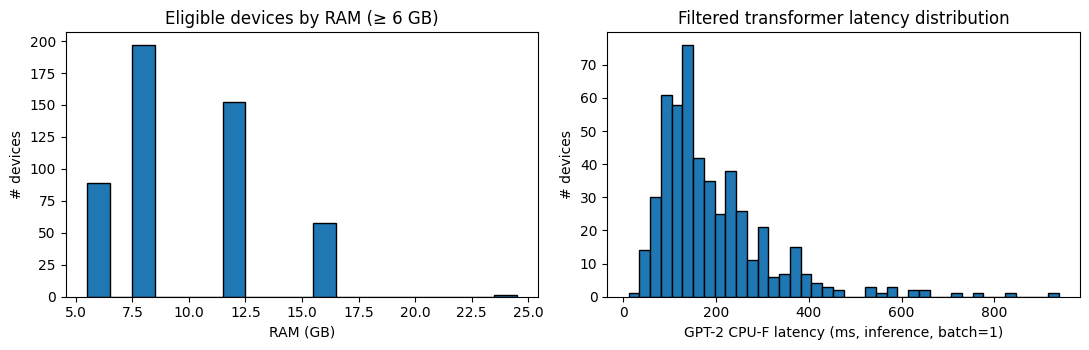

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].hist(elig["ram_gb"], bins=range(RAM_THRESHOLD_GB, 26),
             edgecolor="black", align="left")
axes[0].set_xlabel("RAM (GB)"); axes[0].set_ylabel("# devices")
axes[0].set_title(f"Eligible devices by RAM (≥ {RAM_THRESHOLD_GB} GB)")

axes[1].hist(elig["gpt2_cpu_f_ms"], bins=40, edgecolor="black")
axes[1].set_xlabel("GPT-2 CPU-F latency (ms, inference, batch=1)")
axes[1].set_ylabel("# devices")
axes[1].set_title("Filtered transformer latency distribution")
plt.tight_layout(); plt.show()

## Step 4 — Rank-remap FedScale trace

For every source client, find its percentile in the source distribution, then
look up the GPT-2 latency at that percentile. Trace IDs and the
`communication` field are preserved. New `computation` value is in ms,
scaled by the train multiplier.

In [26]:
with open(SOURCE_TRACE) as f:
    source = json.load(f)
ids   = list(source.keys())
src_c = np.array([source[i]["computation"] for i in ids], dtype=float)
print(f"Source clients: {len(ids):,}")

# Percentile rank in source (0..1, ties broken by average)
src_rank = (np.argsort(np.argsort(src_c)) + 0.5) / len(src_c)

# Sorted target latencies
tgt = np.sort(elig["gpt2_cpu_f_ms"].to_numpy())

# Map percentile -> latency via linear interpolation between sorted target points
tgt_q = np.linspace(0.5 / len(tgt), 1 - 0.5 / len(tgt), len(tgt))
remapped_inference = np.interp(src_rank, tgt_q, tgt)
remapped_train     = remapped_inference * TRAIN_MULTIPLIER

print(f"Remapped (training, ×{TRAIN_MULTIPLIER}):")
print(f"  min={remapped_train.min():.0f} ms  med={np.median(remapped_train):.0f} ms  "
      f"max={remapped_train.max():.0f} ms")

Source clients: 500,000
Remapped (training, ×2.0):
  min=24 ms  med=314 ms  max=1876 ms
Remapped (training, ×2.0):
  min=24 ms  med=314 ms  max=1876 ms


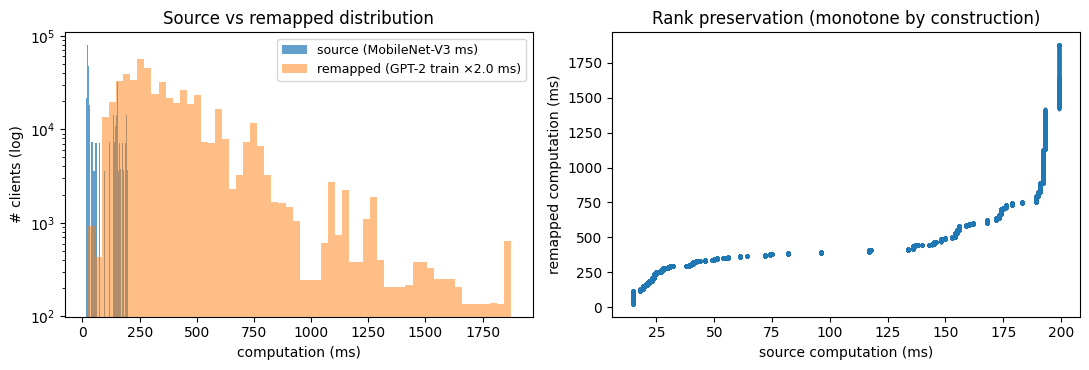

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].hist(src_c, bins=60, alpha=0.7, label="source (MobileNet-V3 ms)")
axes[0].hist(remapped_train, bins=60, alpha=0.5,
             label=f"remapped (GPT-2 train ×{TRAIN_MULTIPLIER} ms)")
axes[0].set_yscale("log")
axes[0].set_xlabel("computation (ms)"); axes[0].set_ylabel("# clients (log)")
axes[0].legend(fontsize=9)
axes[0].set_title("Source vs remapped distribution")

# Rank-preservation check
axes[1].scatter(src_c, remapped_train, s=2, alpha=0.15)
axes[1].set_xlabel("source computation (ms)")
axes[1].set_ylabel("remapped computation (ms)")
axes[1].set_title("Rank preservation (monotone by construction)")
plt.tight_layout(); plt.show()

## Step 5 — Save

Schema is unchanged: same keys, same `communication` values, only `computation`
is replaced. Original FedScale trace is preserved at `_legacy/combined.json`.

In [28]:
out = {
    cid: {
        "computation":   float(round(remapped_train[i], 2)),
        "communication": source[cid]["communication"],
    }
    for i, cid in enumerate(ids)
}
with open(OUT_PATH, "w") as f:
    json.dump(out, f)
print(f"Saved {len(out):,} clients to {OUT_PATH}")

# Also save the eligible-device table for the appendix / reproducibility
elig.drop(columns=["_key"]).to_csv("compute_remap_eligible_devices.csv", index=False)
print(f"Saved eligible-device table to compute_remap_eligible_devices.csv")

Saved 500,000 clients to client_device_capacity.json
Saved eligible-device table to compute_remap_eligible_devices.csv


## Notes / caveats

- **GPT-2 (124M) ≈ ModernBERT-base (149M)** in parameter count, so direct use is
  reasonable for the ModernBERT setup. For Llama-3.2-1B, multiply `TRAIN_MULTIPLIER`
  by an additional ~7× (param ratio, compute-bound assumption) — or recalibrate by
  measuring on 2–3 reference chipsets.
- **CPU-F (float32 inference)** is conservative: real on-device deployments use
  NN-API/INT8 acceleration, so this trace overestimates per-step latency for the
  fastest tier. That's defensible for an FL straggler study.
- **Phone-only sample** — the AI Benchmark table excludes laptops/desktops/tablets.
  Rank-remap neutralizes the population-skew issue (we match percentiles, not
  device counts), but the *shape* of the distribution still reflects only phones.
- **Unmatched models in the join**: any device in the results page that isn't on
  the ranking page is dropped. Coverage is reported in step 3.